# Pipeline vs Single-Node Comparison - Mamba-130M

Compares distributed two-node pipeline inference against the single-node baseline.
Network transfer cost is contextualized using raw ping benchmarks from
`scripts/benchmark_network.py`.

## Data Sources

The CSVs are generated by running:

```bash
python scripts/profile_single_node.py
python scripts/profile_pipeline.py
python scripts/benchmark_network.py --worker <host>:<port>
```

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## Load Data

In [2]:
sn = pd.read_csv("../benchmarks/single_node_baseline.csv")
pp = pd.read_csv("../benchmarks/pipeline_baseline.csv")
pp

,timestamp,hostname,arch,model_name,tokens,pass_type,mean_ms,median_ms,min_ms,max_ms,p95_ms,peak_memory_mb,num_nodes,node_latencies_ms,communication_overhead_ms
0,2026-07-13 19:59:23,fedora,mamba,mamba-130m,64,forward_pass,451.32,451.18,442.04,457.89,457.89,1136,2,"[196.31, 214.52]",40.49
1,2026-07-13 19:59:23,fedora,mamba,mamba-130m,64,generate_30,16380.99,16236.46,15793.03,17105.91,17105.91,1140,2,"[231.94, 268.62]",1364.18
2,2026-07-13 19:59:23,fedora,mamba,mamba-130m,128,forward_pass,917.21,916.88,906.61,931.62,931.62,1142,2,"[381.59, 420.42]",115.20
3,2026-07-13 19:59:23,fedora,mamba,mamba-130m,128,generate_30,29053.07,28967.11,28886.09,29353.20,29353.20,1131,2,"[407.24, 456.71]",3134.84
4,2026-07-13 19:59:23,fedora,mamba,mamba-130m,512,forward_pass,3893.74,3887.27,3859.88,3962.58,3962.58,1291,2,"[1592.13, 1784.58]",517.03
5,2026-07-13 19:59:23,fedora,mamba,mamba-130m,512,generate_30,117992.84,118097.75,117077.27,118682.30,118682.30,1280,2,"[1606.1, 1819.96]",15210.96
6,2026-07-13 19:59:23,fedora,mamba,mamba-130m,1024,forward_pass,8151.89,8160.67,8080.92,8189.81,8189.81,1285,2,"[3377.81, 3757.82]",1016.27
7,2026-07-13 19:59:23,fedora,mamba,mamba-130m,1024,generate_30,232579.20,232711.75,231538.90,233622.31,233622.31,1299,2,"[3167.87, 3582.44]",30070.10


## Latency vs. Sequence Length

Single-node vs. pipeline latency for each pass type. The pipeline adds a
network round-trip per forward call - this chart shows whether that overhead
is significant relative to compute time at each sequence length.

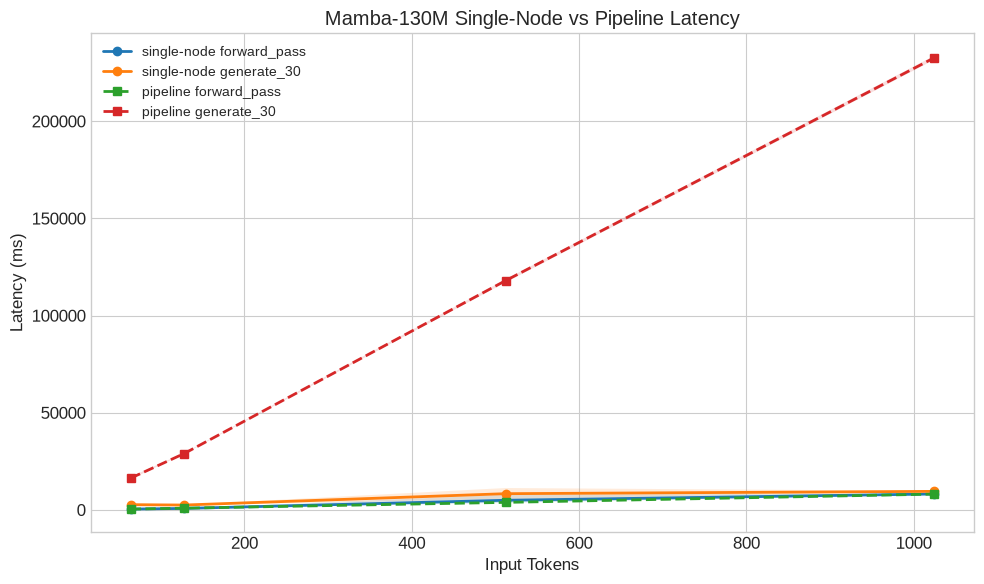

In [3]:
fig, ax = plt.subplots()

for pass_type, group in sn.groupby("pass_type"):
    group = group.sort_values("tokens")
    ax.plot(group["tokens"], group["mean_ms"], marker="o", linewidth=2, label=f"single-node {pass_type}")
    ax.fill_between(group["tokens"], group["min_ms"], group["max_ms"], alpha=0.15)

for pass_type, group in pp.groupby("pass_type"):
    group = group.sort_values("tokens")
    ax.plot(group["tokens"], group["mean_ms"], marker="s", linewidth=2, linestyle="--", label=f"pipeline {pass_type}")
    ax.fill_between(group["tokens"], group["min_ms"], group["max_ms"], alpha=0.15)

ax.set_xlabel("Input Tokens")
ax.set_ylabel("Latency (ms)")
ax.set_title("Mamba-130M Single-Node vs Pipeline Latency")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Per-Node Latency Breakdown

Stacked bars decompose total pipeline latency into per-node compute time and
inter-node communication overhead. A large comm overhead segment indicates the
network is the bottleneck rather than compute.

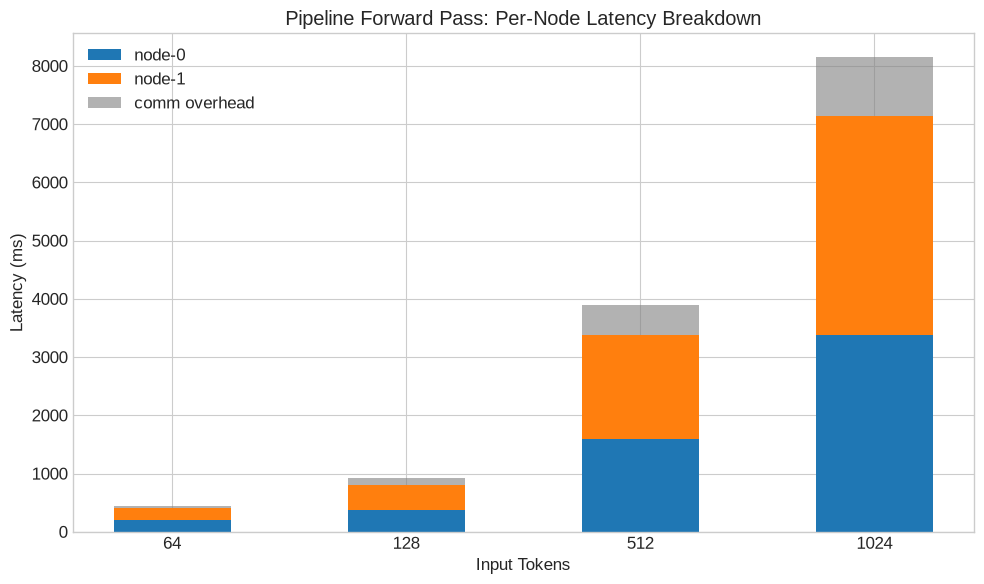

In [4]:
fp = pp[pp["pass_type"] == "forward_pass"].sort_values("tokens").copy()
fp["node_lats"] = fp["node_latencies_ms"].apply(json.loads)
num_nodes = fp["num_nodes"].iloc[0]

x = np.arange(len(fp))
width = 0.5

fig, ax = plt.subplots()

bottom = np.zeros(len(fp))
for node_idx in range(num_nodes):
    values = np.array([row[node_idx] if node_idx < len(row) else 0 for row in fp["node_lats"]])
    ax.bar(x, values, width, bottom=bottom, label=f"node-{node_idx}")
    bottom += values

ax.bar(x, fp["communication_overhead_ms"].values, width, bottom=bottom, label="comm overhead", color="gray", alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(fp["tokens"].astype(str))
ax.set_xlabel("Input Tokens")
ax.set_ylabel("Latency (ms)")
ax.set_title("Pipeline Forward Pass: Per-Node Latency Breakdown")
ax.legend()
plt.tight_layout()
plt.show()

## Communication Overhead vs Network Baseline

Left: raw Ping RTT across payload sizes - establishes the minimum achievable
transfer cost at the network level. Right: pipeline comm overhead plotted
against the 0-byte RTT floor, separating activation transfer cost from
gRPC framing and scheduling jitter.

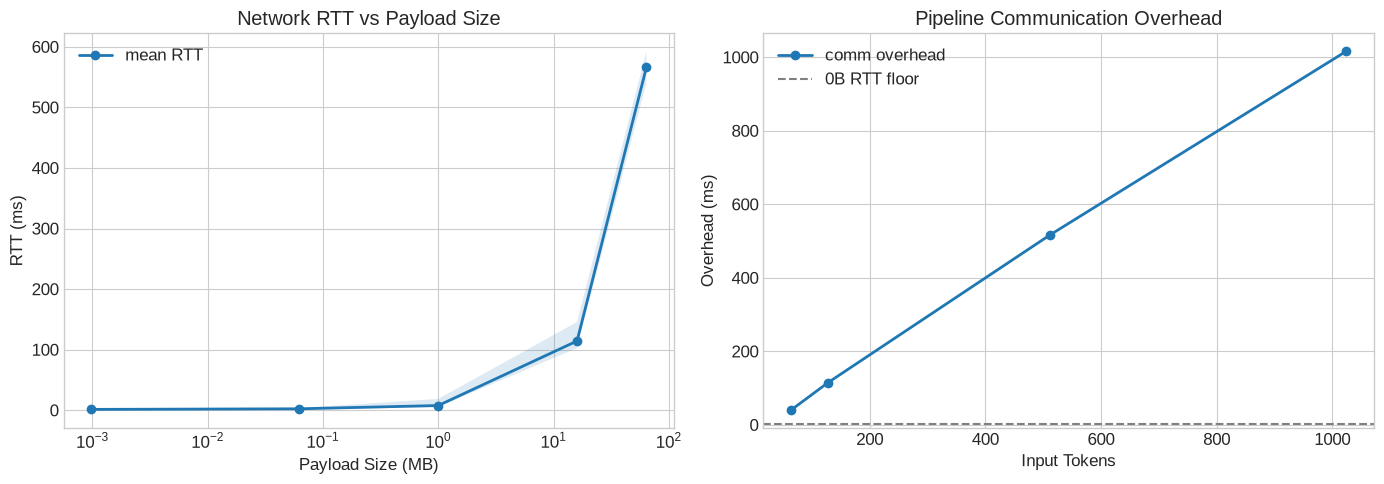

In [5]:
net = pd.read_csv("../benchmarks/network_baseline.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
net_f = net[net["payload_bytes"] > 0].sort_values("payload_bytes")
ax.semilogx(net_f["payload_bytes"] / (1024 * 1024), net_f["mean_ms"], marker="o", linewidth=2, label="mean RTT")
ax.fill_between(net_f["payload_bytes"] / (1024 * 1024), net_f["min_ms"], net_f["max_ms"], alpha=0.15)
ax.set_xlabel("Payload Size (MB)")
ax.set_ylabel("RTT (ms)")
ax.set_title("Network RTT vs Payload Size")
ax.legend()

ax = axes[1]
fp_comm = pp[pp["pass_type"] == "forward_pass"].sort_values("tokens")
ax.plot(fp_comm["tokens"], fp_comm["communication_overhead_ms"], marker="o", linewidth=2, label="comm overhead")
ax.axhline(y=net[net["payload_bytes"] == 0]["mean_ms"].mean(), linestyle="--", color="gray", label="0B RTT floor")
ax.set_xlabel("Input Tokens")
ax.set_ylabel("Overhead (ms)")
ax.set_title("Pipeline Communication Overhead")
ax.legend()

plt.tight_layout()
plt.show()

## Summary Table

In [6]:
sn_s = sn[["hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb"]].copy()
sn_s["mode"] = "single-node"

pp_s = pp[["hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb", "num_nodes"]].copy()
pp_s["mode"] = pp_s["num_nodes"].apply(lambda n: f"pipeline-{n}")

summary = pd.concat([
    sn_s[["mode", "hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb"]],
    pp_s[["mode", "hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb"]],
], ignore_index=True).sort_values(["pass_type", "tokens", "mode"])

summary.columns = ["Mode", "Host", "Tokens", "Pass Type", "Mean (ms)", "Median (ms)", "P95 (ms)", "Peak Mem (MB)"]
summary

,Mode,Host,Tokens,Pass Type,Mean (ms),Median (ms),P95 (ms),Peak Mem (MB)
8,pipeline-2,fedora,64,forward_pass,451.32,451.18,457.89,1136
0,single-node,fedora,64,forward_pass,452.37,448.74,493.59,862
10,pipeline-2,fedora,128,forward_pass,917.21,916.88,931.62,1142
2,single-node,fedora,128,forward_pass,787.96,778.55,827.63,880
12,pipeline-2,fedora,512,forward_pass,3893.74,3887.27,3962.58,1291
4,single-node,fedora,512,forward_pass,4982.62,4476.24,7789.66,868
14,pipeline-2,fedora,1024,forward_pass,8151.89,8160.67,8189.81,1285
6,single-node,fedora,1024,forward_pass,8212.22,8196.63,8429.52,808
9,pipeline-2,fedora,64,generate_30,16380.99,16236.46,17105.91,1140
1,single-node,fedora,64,generate_30,2702.96,2556.41,3523.20,855
